# Exploratory Data Analysis
## AI-Powered Financial Analyst

In [ ]:
import os
import sys

# 1. Get the absolute path to the 'root
root_path = os.path.abspath(os.path.join('..'))

# 2. Add the root path to sys.path to import 'src'
if root_path not in sys.path:
    sys.path.append(root_path)

# 3. Now import using the 'src.' prefix
from src.data_loader import load_and_preprocess_stock_data, get_clean_data_path

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.tsa.stattools import adfuller

TARGET_TICKER = "AAPL"
START_DATE = "2023-01-01"
END_DATE = "2025-01-01"
SEQUENCE_LENGTH = 60

print("--- Loading and Preprocessing Data for EDA ---")
scaled_df, X_train, y_train, X_test, y_test, scaler_features, scaler_target, feature_columns = \
    load_and_preprocess_stock_data(
        ticker=TARGET_TICKER,
        start_date=START_DATE,
        end_date=END_DATE,
        sequence_length=SEQUENCE_LENGTH
    )

raw_processed_df = pd.read_csv(
    get_clean_data_path(TARGET_TICKER),
    index_col='Date',
    parse_dates=True
)
print("\n--- Raw Processed Data Head ---")
print(raw_processed_df.head())
print("\n--- Raw Processed Data Info ---")
raw_processed_df.info()

--- Loading and Preprocessing Data for EDA ---
Loading data for AAPL from 2023-01-01 to 2025-01-01...


[*********************100%***********************]  1 of 1 completed

Data loading and preprocessing complete. X_train shape: (314, 60, 12), X_test shape: (79, 60, 12)
Cleaned data saved to d:\USD\capstone\data\clean_stock_data_AAPL.csv

--- Raw Processed Data Head ---
             Adj Close       Close        High         Low        Open  \
Date                                                                     
2023-03-15  150.666458  152.990005  153.250000  149.919998  151.190002   
2023-03-16  153.483017  155.850006  156.460007  151.639999  152.160004   
2023-03-17  152.645950  155.000000  156.740005  154.279999  156.080002   
2023-03-20  155.009445  157.399994  157.820007  154.149994  155.070007   
2023-03-21  156.860947  159.279999  159.399994  156.539993  157.320007   

              Volume  Daily_Return        MA20      MA50  Volatility  \
Date                                                                   
2023-03-15  77167900      0.002621  150.305501  144.7934    0.015159   
2023-03-16  76161100      0.018694  150.331501  145.4090    0.015

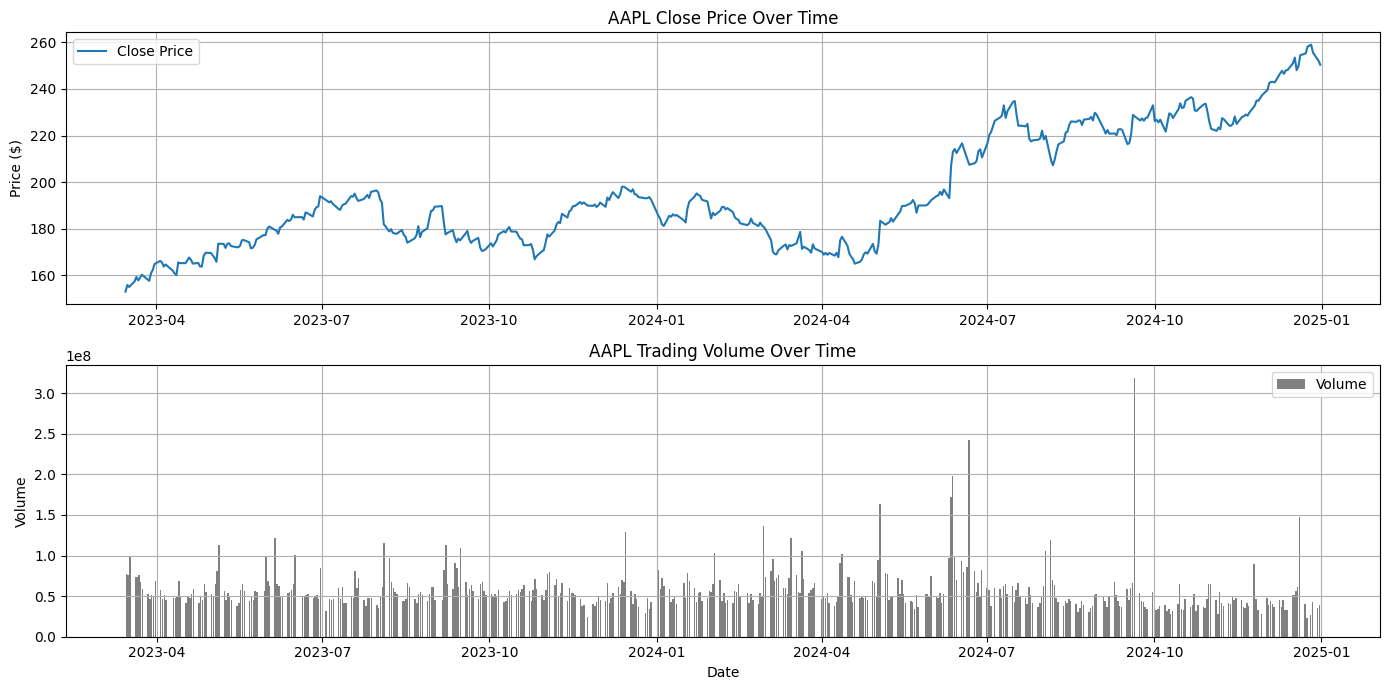

In [7]:
# Basic Price and Volume Trends
plt.figure(figsize=(14, 7))
plt.subplot(2, 1, 1)
plt.plot(raw_processed_df.index, raw_processed_df['Close'], label='Close Price')
plt.title(f'{TARGET_TICKER} Close Price Over Time')
plt.ylabel('Price ($)')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.bar(raw_processed_df.index, raw_processed_df['Volume'], label='Volume', color='gray')
plt.title(f'{TARGET_TICKER} Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

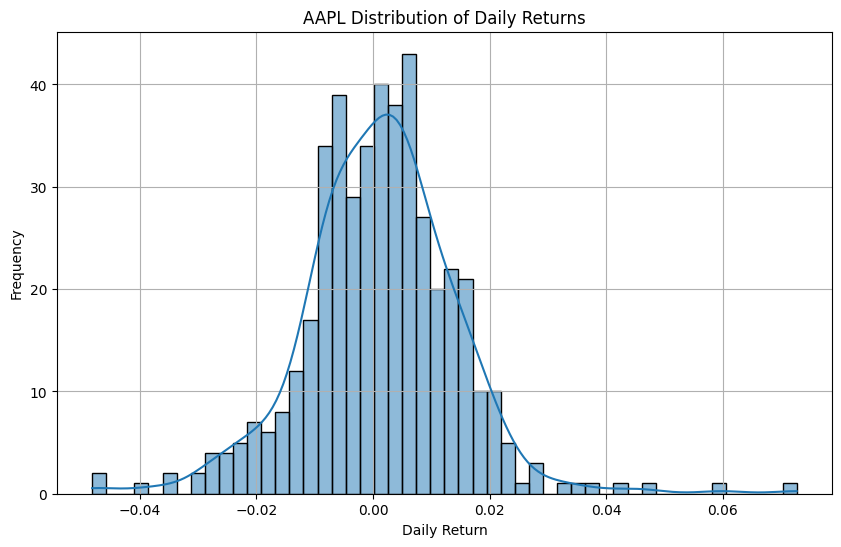

In [8]:
# Daily Returns Distribution
plt.figure(figsize=(10, 6))
sns.histplot(raw_processed_df['Daily_Return'].dropna(), bins=50, kde=True)
plt.title(f'{TARGET_TICKER} Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

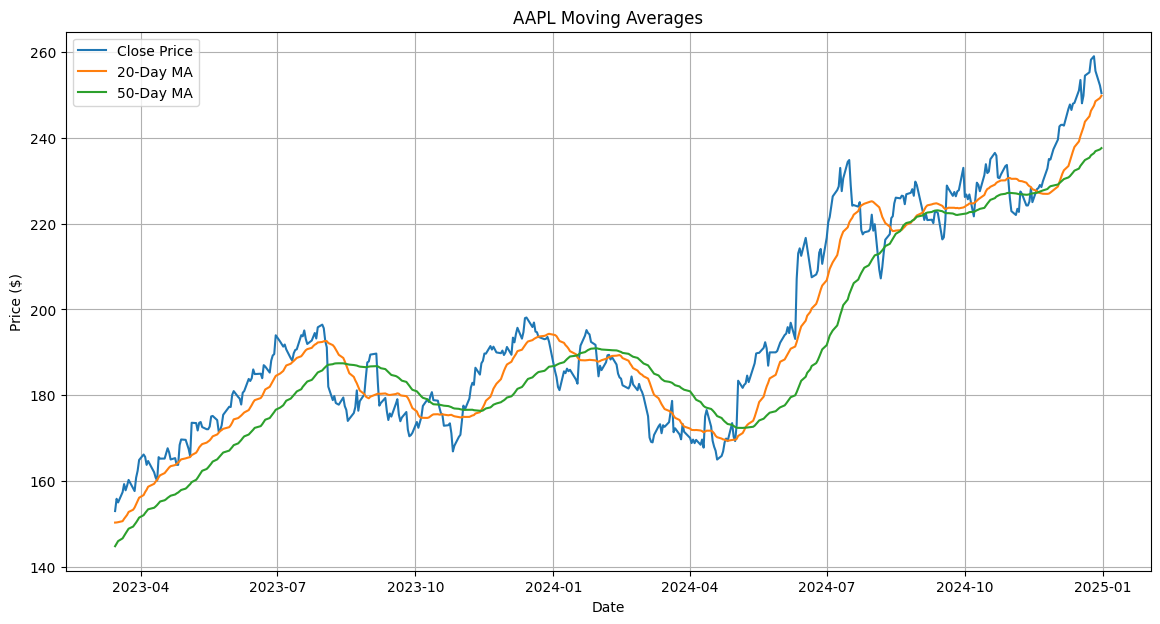

In [9]:
# Moving Averages
plt.figure(figsize=(14, 7))
plt.plot(raw_processed_df.index, raw_processed_df['Close'], label='Close Price')
plt.plot(raw_processed_df.index, raw_processed_df['MA20'], label='20-Day MA')
plt.plot(raw_processed_df.index, raw_processed_df['MA50'], label='50-Day MA')
plt.title(f'{TARGET_TICKER} Moving Averages')
plt.ylabel('Price ($)')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.show()

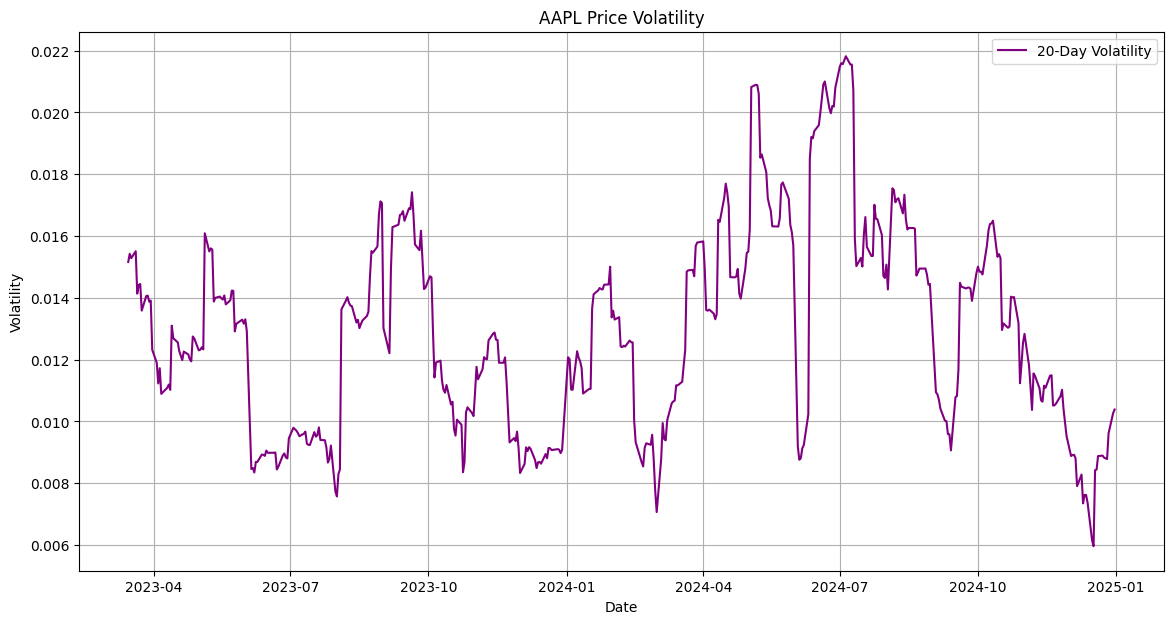

In [10]:
# Volatility
plt.figure(figsize=(14, 7))
plt.plot(raw_processed_df.index, raw_processed_df['Volatility'], label='20-Day Volatility', color='purple')
plt.title(f'{TARGET_TICKER} Price Volatility')
plt.ylabel('Volatility')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.show()

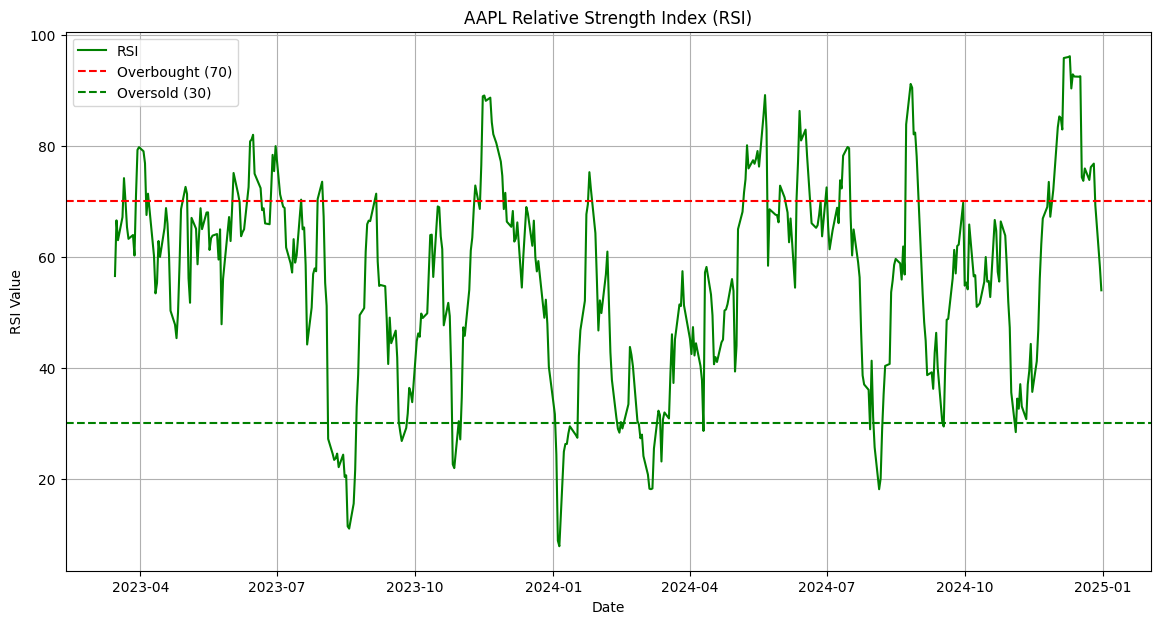

In [11]:
# Relative Strength Index (RSI)
plt.figure(figsize=(14, 7))
plt.plot(raw_processed_df.index, raw_processed_df['RSI'], label='RSI', color='green')
plt.axhline(70, linestyle='--', color='red', label='Overbought (70)')
plt.axhline(30, linestyle='--', color='green', label='Oversold (30)')
plt.title(f'{TARGET_TICKER} Relative Strength Index (RSI)')
plt.ylabel('RSI Value')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.show()

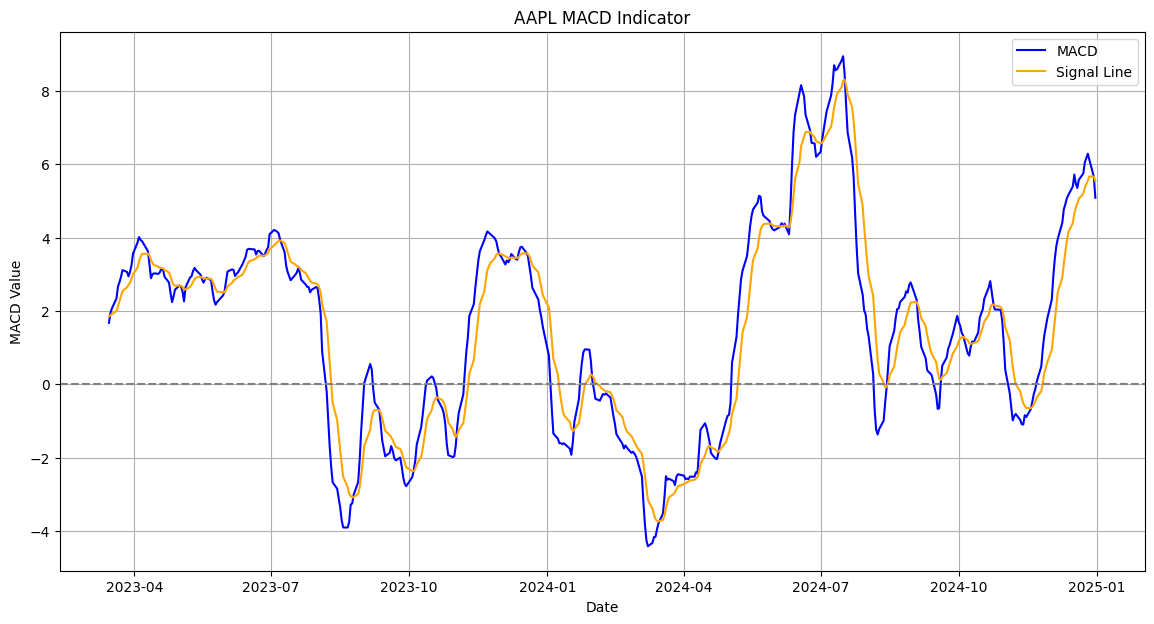

In [12]:
# MACD
plt.figure(figsize=(14, 7))
plt.plot(raw_processed_df.index, raw_processed_df['MACD'], label='MACD', color='blue')
plt.plot(raw_processed_df.index, raw_processed_df['Signal_Line'], label='Signal Line', color='orange')
plt.axhline(0, linestyle='--', color='gray')
plt.title(f'{TARGET_TICKER} MACD Indicator')
plt.ylabel('MACD Value')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.show()

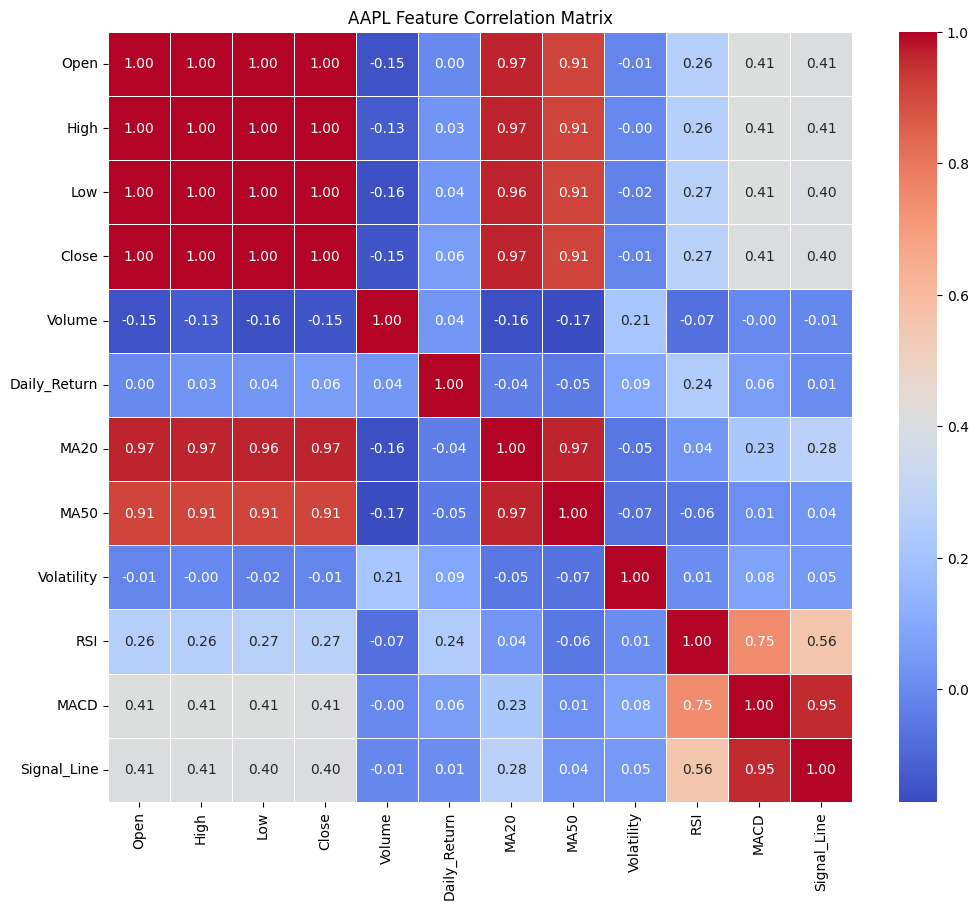

In [13]:
# Correlation Matrix
plt.figure(figsize=(12, 10))
corr_df = raw_processed_df[
    ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return',
     'MA20', 'MA50', 'Volatility', 'RSI', 'MACD', 'Signal_Line']
].dropna()
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title(f'{TARGET_TICKER} Feature Correlation Matrix')
plt.show()

In [14]:
# Stationarity Check (Augmented Dickey-Fuller Test)
print(f"\n--- Augmented Dickey-Fuller Test for {TARGET_TICKER} Close Price ---")
adf_test_close = adfuller(raw_processed_df['Close'].dropna())
print(f"ADF Statistic (Close): {adf_test_close[0]:.2f}")
print(f"p-value (Close): {adf_test_close[1]:.3f}")
print("Critical Values (Close):")
for key, value in adf_test_close[4].items():
    print(f"   {key}: {value:.2f}")

if adf_test_close[1] < 0.05:
    print("Conclusion: Close price series is likely stationary (reject H0).")
else:
    print("Conclusion: Close price series is likely non-stationary (fail to reject H0).")
    print("Recommendation: Consider differencing the series if using traditional time series models. For LSTMs, scaling is often sufficient.")

print(f"\n--- Augmented Dickey-Fuller Test for {TARGET_TICKER} Daily Returns ---")
adf_test_returns = adfuller(raw_processed_df['Daily_Return'].dropna())
print(f"ADF Statistic (Daily Return): {adf_test_returns[0]:.2f}")
print(f"p-value (Daily Return): {adf_test_returns[1]:.3f}")
print("Critical Values (Daily Return):")
for key, value in adf_test_returns[4].items():
    print(f"   {key}: {value:.2f}")

if adf_test_returns[1] < 0.05:
    print("Conclusion: Daily Return series is likely stationary (reject H0). This is good for many models.")
else:
    print("Conclusion: Daily Return series is likely non-stationary (fail to reject H0).")


--- Augmented Dickey-Fuller Test for AAPL Close Price ---
ADF Statistic (Close): -0.66
p-value (Close): 0.856
Critical Values (Close):
   1%: -3.44
   5%: -2.87
   10%: -2.57
Conclusion: Close price series is likely non-stationary (fail to reject H0).
Recommendation: Consider differencing the series if using traditional time series models. For LSTMs, scaling is often sufficient.

--- Augmented Dickey-Fuller Test for AAPL Daily Returns ---
ADF Statistic (Daily Return): -19.78
p-value (Daily Return): 0.000
Critical Values (Daily Return):
   1%: -3.44
   5%: -2.87
   10%: -2.57
Conclusion: Daily Return series is likely stationary (reject H0). This is good for many models.
